In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
from hsflfm.analysis import ResultManager 
from hsflfm.util import load_image_set, load_dictionary 
from PIL import Image 

This notebook is not part of the pipeline, but it is a helpful tool when performing manual translation to check the accuracy of the pipeline. Cells and be used to see if matched points line up with camera views and the quality of optical flow.

In [68]:
# swap in where your files are stored, and which frames you want to check 
# this could be automated but I don't know your naming conventions
folder = "C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B"
filename0 = folder + '/20260526_B_0_0_0.tiff'
filename1 = folder + '/20260526_B_1_5_0.tiff' 
filename2 = folder + '/20260526_B_3_5_0.tiff'
filename3 = folder + '/20260526_B_5_5_0.tiff'
filename4 = folder + '/20260526_B_7_5_0.tiff'



filenames = [filename0, filename1, filename2, filename3, filename4]
frames = [0, 10, 20, 30, 40]

# adjust to match your file locations 
results = load_dictionary(folder + '/strike_1_results.json')
calibration_filename = folder + '/calibration_images/calibration_information'

image_sets = [load_image_set(i, calibration_filename) for i in filenames]


In [69]:
# pick any camera number of loop through them 
cam_num = 1
match_points = np.asarray(results["match_points"][cam_num])
flow_cam = np.asarray(results["flow_vectors"])[:, 2 * cam_num:2 * cam_num + 2]

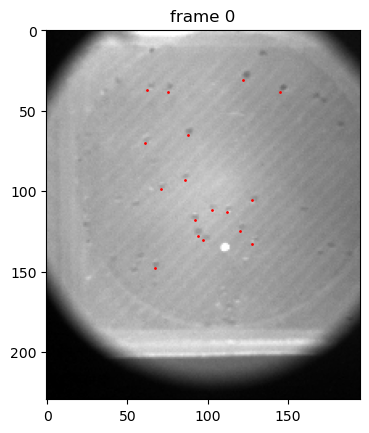

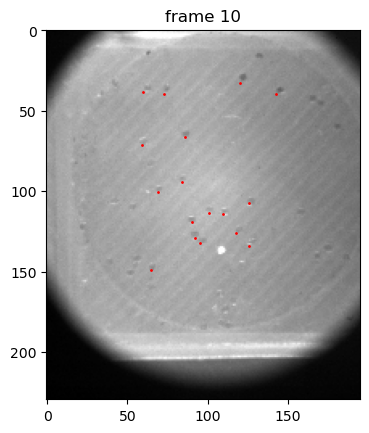

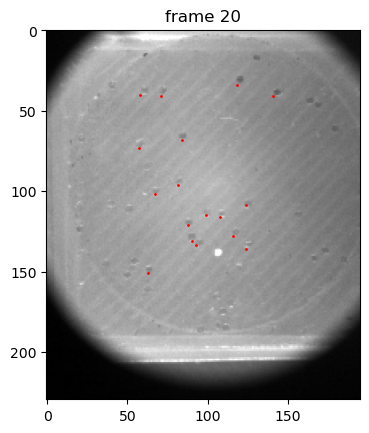

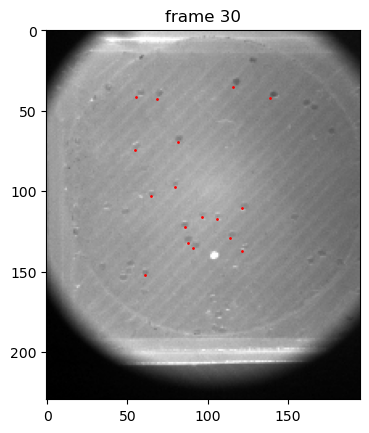

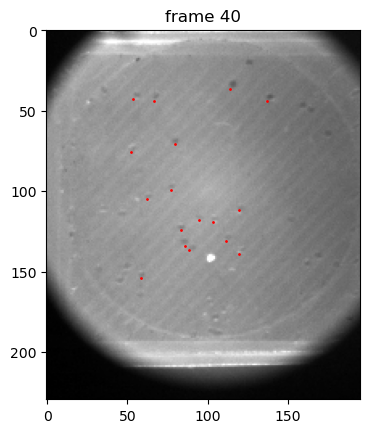

In [70]:
for image_set, frame in zip(image_sets, frames):
    image = image_set[cam_num] 
    locations = match_points[:, :2] + flow_cam[:, :, frame]
    plt.figure()
    plt.imshow(image, cmap='gray')
    plt.scatter(locations[:, 1], locations[:, 0], s=1, c='r')
    plt.title(f"frame {frame}")
    plt.show()

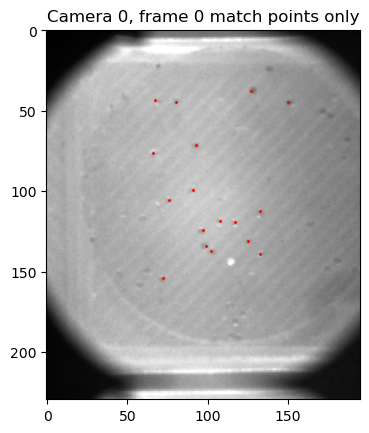

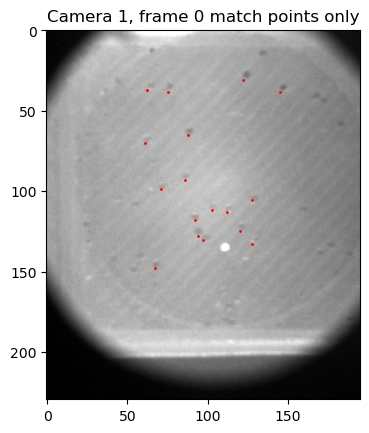

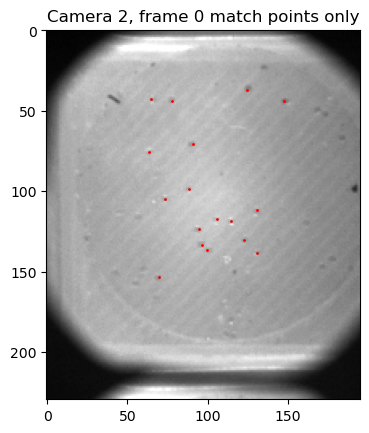

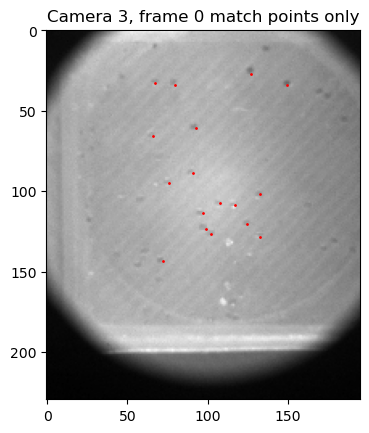

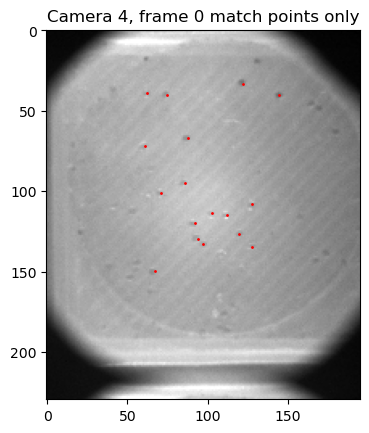

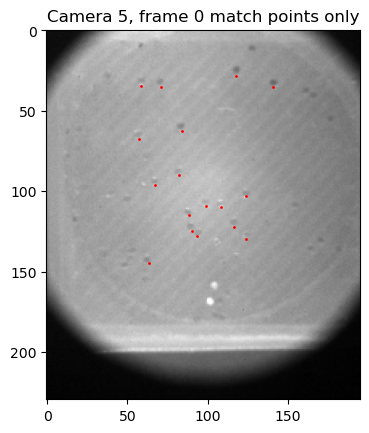

In [67]:
for cam_num in range(6):
    image = image_sets[0][cam_num]
    match_points = np.asarray(results["match_points"][cam_num])
    locations = match_points[:, :2]

    plt.figure()
    plt.imshow(image, cmap="gray")
    plt.scatter(locations[:, 1], locations[:, 0], s=1, c="r")
    plt.title(f"Camera {cam_num}, frame 0 match points only")
    plt.show()

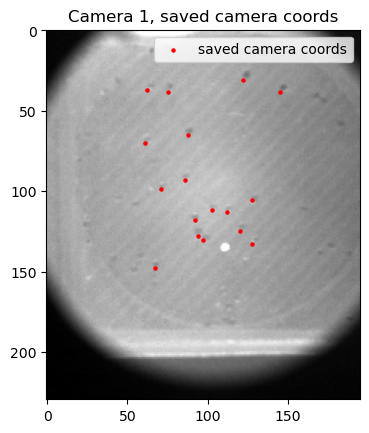

[[6.48898087e+01 8.79065933e+01 3.01504135e-02 7.10000000e+01
  9.10000000e+01]
 [9.27718124e+01 8.59130630e+01 3.01504135e-02 9.90000000e+01
  8.90000000e+01]
 [1.17677803e+02 9.18790436e+01 3.01504135e-02 1.24000000e+02
  9.50000000e+01]
 [1.27644287e+02 9.38661957e+01 3.01504135e-02 1.34000000e+02
  9.70000000e+01]
 [1.30633301e+02 9.68516006e+01 3.01504135e-02 1.37000000e+02
  1.00000000e+02]]


In [71]:
cam_num = 1
pts = np.asarray(results["match_points"][cam_num])
image = image_sets[0][cam_num]

plt.figure()
plt.imshow(image, cmap="gray")

# saved camera-space locations
plt.scatter(pts[:, 1], pts[:, 0], s=5, c="r", label="saved camera coords")

plt.legend()
plt.title(f"Camera {cam_num}, saved camera coords")
plt.show()

print(pts[:5])

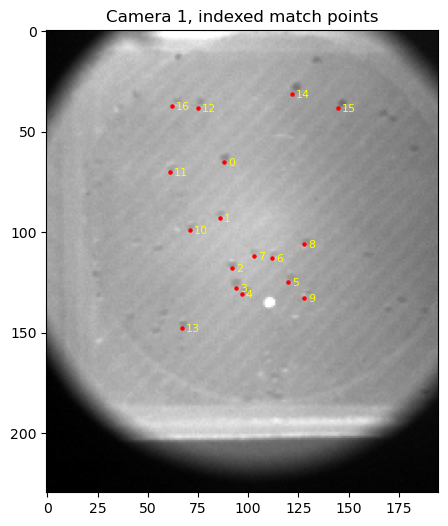

In [72]:
cam_num = 1
pts = np.asarray(results["match_points"][cam_num])
image = image_sets[0][cam_num]

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.scatter(pts[:, 1], pts[:, 0], s=5, c="r")

for i, p in enumerate(pts):
    plt.text(p[1] + 2, p[0] + 2, str(i), color="yellow", fontsize=8)

plt.title(f"Camera {cam_num}, indexed match points")
plt.show()

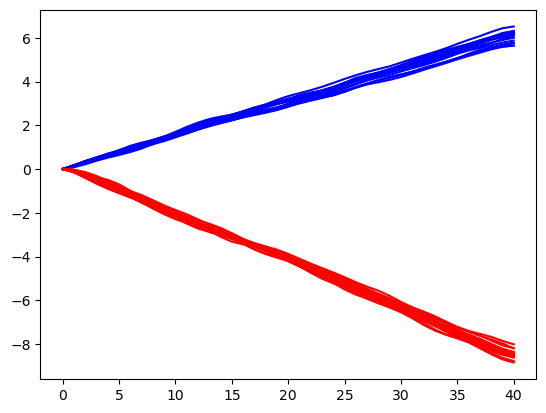

In [8]:
# look at the flow vectors themselves
_ = plt.plot(flow_cam[:, 0].T, label='x flow', color='blue')
_ = plt.plot(flow_cam[:, 1].T, label='y flow', color='red')

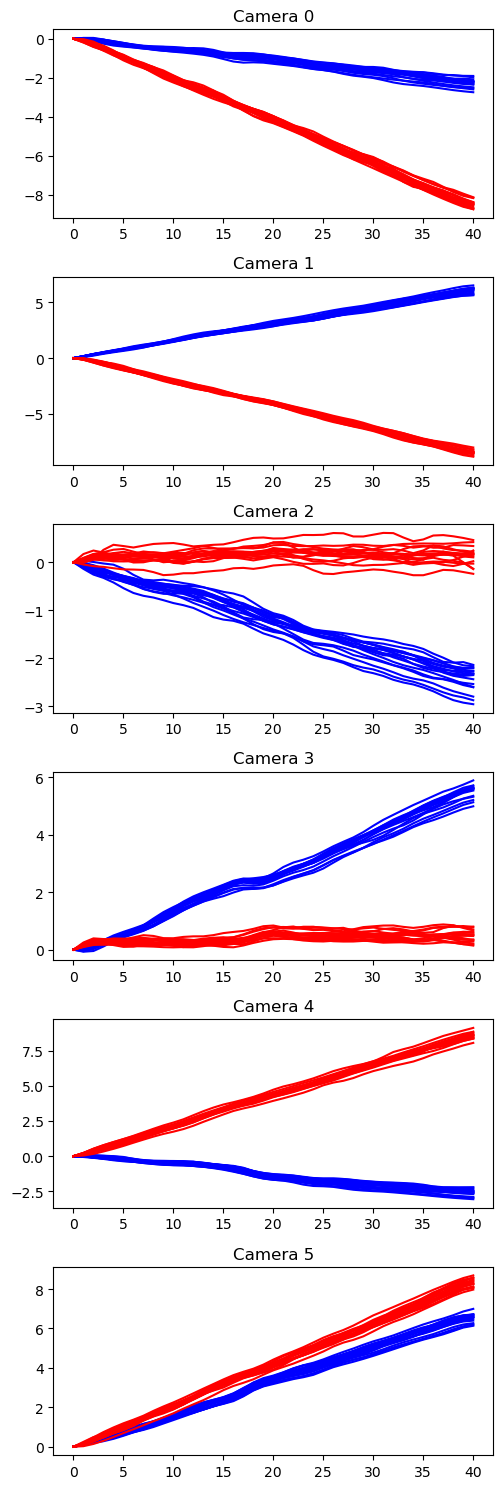

In [9]:
# look at flow vectors for all cameras 
flow_vectors = np.asarray(results["flow_vectors"])
num_cams = flow_vectors.shape[1] // 2 
fig, axes = plt.subplots(num_cams, 1, figsize=(5, 15))
for cam_num in range(num_cams):
    ax = axes[cam_num]
    flow_cam = flow_vectors[:, 2 * cam_num:2 * cam_num + 2]
    _ = ax.plot(flow_cam[:, 0].T, label='x flow', color='blue')
    _ = ax.plot(flow_cam[:, 1].T, label='y flow', color='red')
    ax.set_title(f"Camera {cam_num}")

plt.tight_layout() 

In [73]:
from hsflfm.util import MetadataManager, load_dictionary, load_split_video
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

# -------------------------
# User settings
# -------------------------
#specimen = "20260602_B_1"
specimen = "20260526_B"
strike_number = 1
cam_num = 5

# -------------------------
# Load actual trial video and processed results
# -------------------------
mm = MetadataManager(specimen)

video_filename = mm.video_filename(strike_number)
calibration_filename = mm.calibration_filename

print("Video:", video_filename)
print("Calibration:", calibration_filename)
print("Match points:", mm.match_points_filename)

videos = load_split_video(video_filename, calibration_filename)

# Convert to grayscale if needed
for key, item in videos.items():
    if len(item.shape) > 3:
        videos[key] = np.mean(item, axis=-1)

results_file = Path("../processed_results") / f"results_{specimen}" / specimen / f"strike_{strike_number}_results.json"

print(results_file.resolve())
print(results_file.exists())

results = load_dictionary(str(results_file))

match_points = np.asarray(results["match_points"][cam_num])
flow_cam = np.asarray(results["flow_vectors"])[:, 2 * cam_num : 2 * cam_num + 2]

Video: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B/20260526.avi
Calibration: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B/calibration_images/calibration_information
Match points: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260526_B/match_points
C:\Users\abhin\HighSpeedFLFM\processed_results\results_20260526_B\20260526_B\strike_1_results.json
True


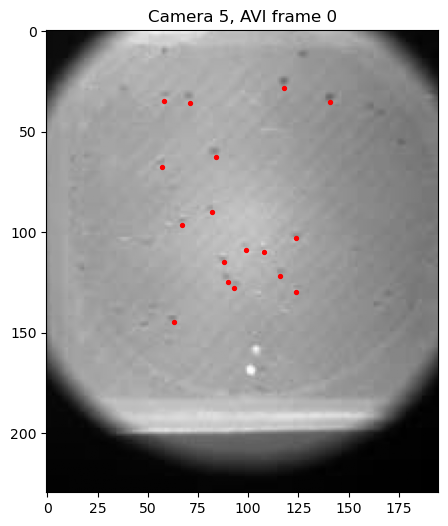

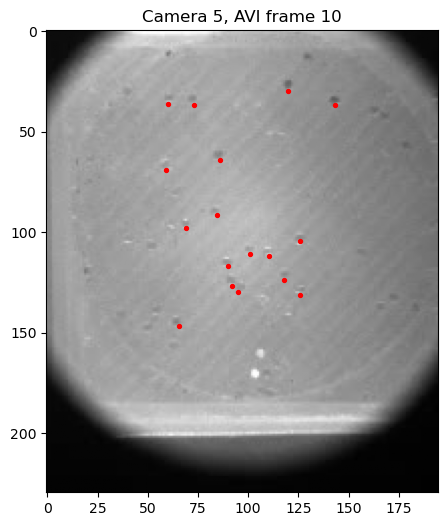

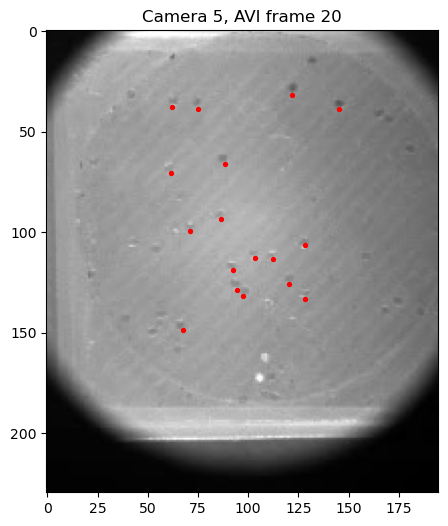

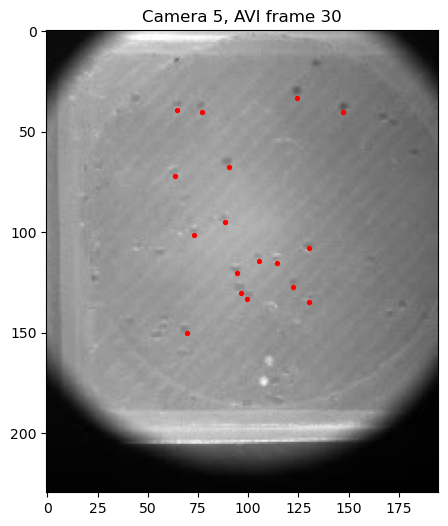

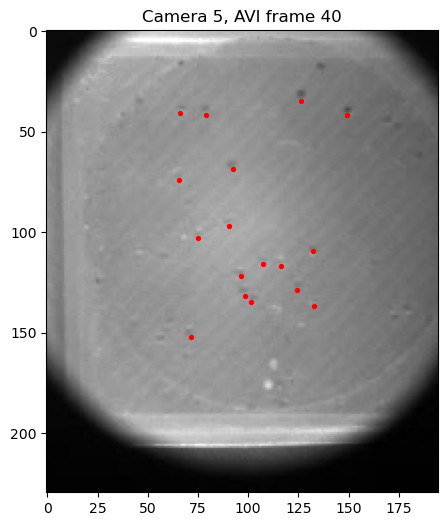

In [74]:
frames = [0, 10, 20, 30, 40]

for frame in frames:
    image = videos[cam_num][frame]

    locations = match_points[:, :2] + flow_cam[:, :, frame]

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.scatter(locations[:, 1], locations[:, 0], s=8, c="r")
    plt.title(f"Camera {cam_num}, AVI frame {frame}")
    plt.show()

In [75]:
from hsflfm.util import MetadataManager, load_dictionary
import numpy as np

mm = MetadataManager(specimen)

raw_match_points = load_dictionary(mm.match_points_filename)
processed_match_points = results["match_points"]

for cam_num in raw_match_points.keys():
    raw = np.asarray(raw_match_points[cam_num])[:, :2]
    processed = np.asarray(processed_match_points[cam_num])[:, :2]

    diff = processed - raw

    print(f"Camera {cam_num}")
    print("max abs difference:", np.max(np.abs(diff)))
    print("mean difference:", np.mean(diff, axis=0))
    print()

Camera 0
max abs difference: 0.0
mean difference: [0. 0.]

Camera 1
max abs difference: 0.0
mean difference: [0. 0.]

Camera 2
max abs difference: 0.0
mean difference: [0. 0.]

Camera 3
max abs difference: 0.0
mean difference: [0. 0.]

Camera 4
max abs difference: 0.0
mean difference: [0. 0.]

Camera 5
max abs difference: 0.0
mean difference: [0. 0.]



In [76]:
flow_vectors = np.asarray(results["flow_vectors"])

for cam_num in range(flow_vectors.shape[1] // 2):
    flow0 = flow_vectors[:, 2 * cam_num:2 * cam_num + 2, 0]

    print(f"Camera {cam_num}")
    print("max abs frame 0 flow:", np.max(np.abs(flow0)))
    print("mean frame 0 flow:", np.mean(flow0, axis=0))
    print()

Camera 0
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]

Camera 1
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]

Camera 2
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]

Camera 3
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]

Camera 4
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]

Camera 5
max abs frame 0 flow: 0.0
mean frame 0 flow: [0. 0.]



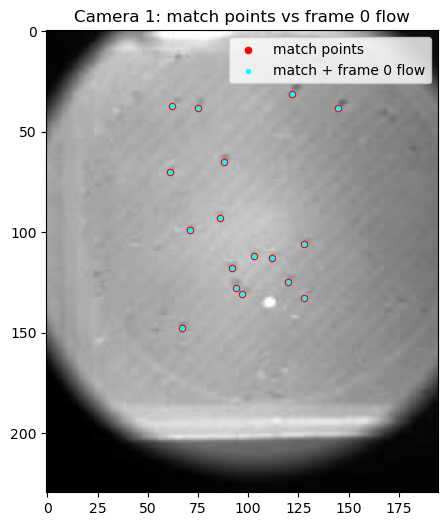

In [77]:
cam_num = 1
image = videos[cam_num][0]
pts = np.asarray(results["match_points"][cam_num])
flow0 = flow_vectors[:, 2 * cam_num:2 * cam_num + 2, 0]

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")

# Raw saved match points
plt.scatter(pts[:, 1], pts[:, 0], s=20, c="r", label="match points")

# Match points + frame 0 flow
loc0 = pts[:, :2] + flow0
plt.scatter(loc0[:, 1], loc0[:, 0], s=8, c="cyan", label="match + frame 0 flow")

plt.legend()
plt.title(f"Camera {cam_num}: match points vs frame 0 flow")
plt.show()

In [78]:
start_images = mm.get_start_images(strike_number=1)

for cam_num in range(6):
    avi_frame0 = videos[cam_num][0].astype(float)
    start_img = start_images[cam_num].astype(float)

    diff = avi_frame0 - start_img

    print(f"Camera {cam_num}")
    print("max abs image diff:", np.max(np.abs(diff)))
    print("mean abs image diff:", np.mean(np.abs(diff)))
    print()

Camera 0
max abs image diff: 47.5
mean abs image diff: 2.8934126099343493

Camera 1
max abs image diff: 73.0
mean abs image diff: 2.712243280069368

Camera 2
max abs image diff: 26.333333333333343
mean abs image diff: 2.574132292827945

Camera 3
max abs image diff: 31.666666666666686
mean abs image diff: 2.3213935340022305

Camera 4
max abs image diff: 34.16666666666666
mean abs image diff: 2.610442214790042

Camera 5
max abs image diff: 58.333333333333314
mean abs image diff: 2.6563879598662234



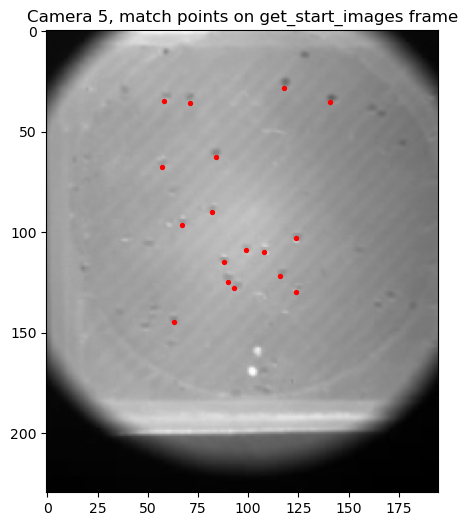

In [80]:
start_images = mm.get_start_images(strike_number=1)

cam_num = 5
image = start_images[cam_num]
pts = np.asarray(results["match_points"][cam_num])

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.scatter(pts[:, 1], pts[:, 0], s=8, c="r")
plt.title(f"Camera {cam_num}, match points on get_start_images frame")
plt.show()

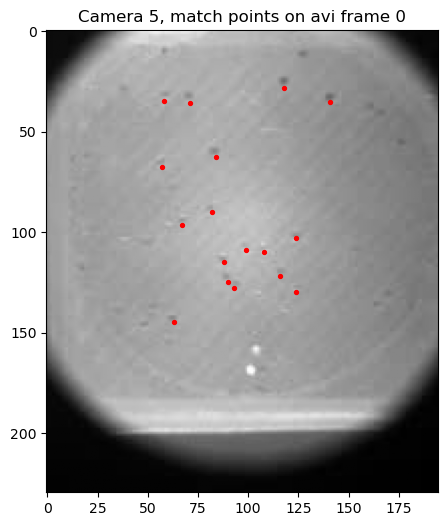

In [86]:
start_images = mm.get_start_images(strike_number=1)

cam_num = 5
image = videos[cam_num][0]
pts = np.asarray(results["match_points"][cam_num])

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.scatter(pts[:, 1], pts[:, 0], s=8, c="r")
plt.title(f"Camera {cam_num}, match points on avi frame 0")
plt.show()

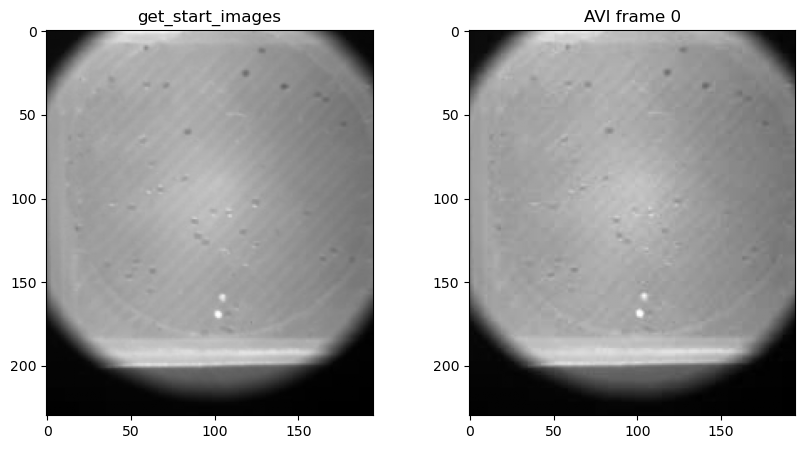

In [87]:
avi0 = videos[cam_num][0]
start0 = start_images[cam_num]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(start0, cmap="gray")
ax[0].set_title("get_start_images")

ax[1].imshow(avi0, cmap="gray")
ax[1].set_title("AVI frame 0")

plt.show()

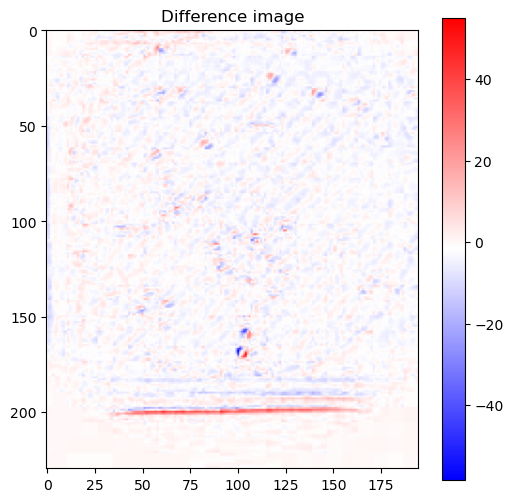

In [88]:
plt.figure(figsize=(6,6))
plt.imshow(start0.astype(float) - avi0.astype(float), cmap="bwr")
plt.colorbar()
plt.title("Difference image")
plt.show()

In [91]:
from hsflfm.util import MetadataManager, load_dictionary, load_split_video
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

# -------------------------
# User settings
# -------------------------
#specimen = "20260602_B_1"
specimen = "20260528_B"
strike_number = 1
cam_num = 3

# -------------------------
# Load actual trial video and processed results
# -------------------------
mm = MetadataManager(specimen)

video_filename = mm.video_filename(strike_number)
calibration_filename = mm.calibration_filename

print("Video:", video_filename)
print("Calibration:", calibration_filename)
print("Match points:", mm.match_points_filename)

videos = load_split_video(video_filename, calibration_filename)

# Convert to grayscale if needed
for key, item in videos.items():
    if len(item.shape) > 3:
        videos[key] = np.mean(item, axis=-1)

results_file = Path("../processed_results") / f"results_{specimen}" / specimen / f"strike_{strike_number}_results.json"

print(results_file.resolve())
print(results_file.exists())

results = load_dictionary(str(results_file))

match_points = np.asarray(results["match_points"][cam_num])
flow_cam = np.asarray(results["flow_vectors"])[:, 2 * cam_num : 2 * cam_num + 2]

Video: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260528_B/20260528_B_2a.avi
Calibration: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260528_B/calibration_images/calibration_information
Match points: C:/Users/abhin/Box/Vaduri_Abhinav Jumping Shells/Collected_Disk_Videos/20260528_B/match_points
C:\Users\abhin\HighSpeedFLFM\processed_results\results_20260528_B\20260528_B\strike_1_results.json
True


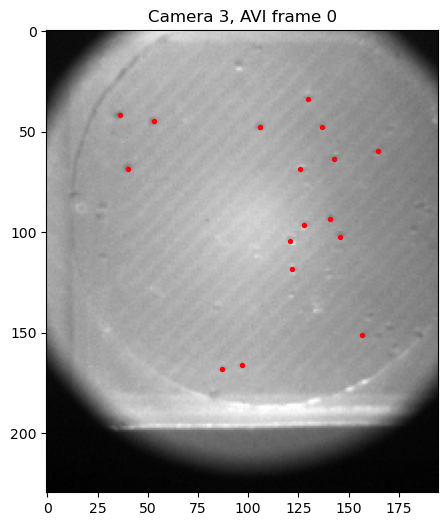

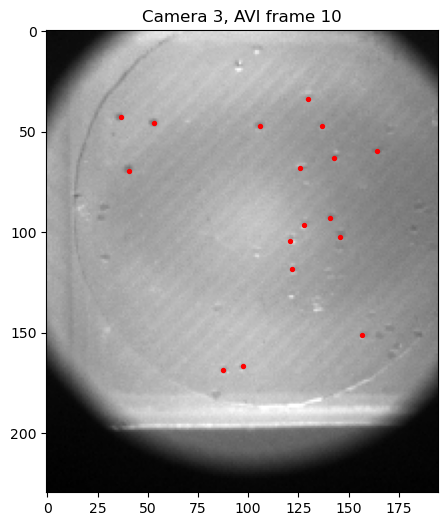

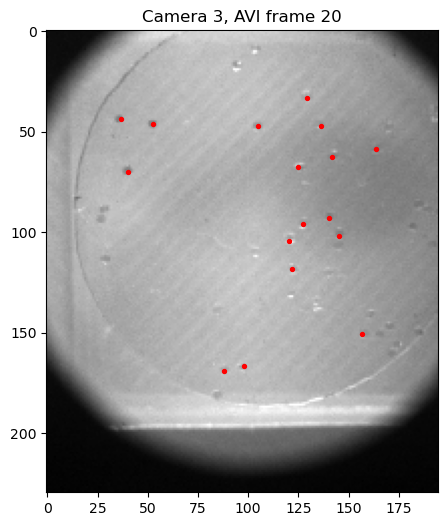

IndexError: index 30 is out of bounds for axis 0 with size 26

In [92]:
frames = [0, 10, 20, 30, 40]

for frame in frames:
    image = videos[cam_num][frame]

    locations = match_points[:, :2] + flow_cam[:, :, frame]

    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap="gray")
    plt.scatter(locations[:, 1], locations[:, 0], s=8, c="r")
    plt.title(f"Camera {cam_num}, AVI frame {frame}")
    plt.show()